# ResNet-50 + Wavelet Features (Hybrid) v3 — Breast Cancer Classification
Based on: Mohanty & Das (2025), *ResNet-50 backbone + wavelet features for complementary information*.

## v1 -> v2 -> v3, based on actually running each version

- **v1**: flat `MALIGNANT_BOOST = 1.3`, DWT-only wavelet features. Test F1 74.42%. Benign recall 0.57,
  Malignant recall 0.82 (strong), Benign-vs-Malignant accuracy ~71.7% (derived from the confusion matrix).
  This baseline already beat every version of the separate semi-supervised `Fused_SemiSupervised_
  ResNet50_Wavelet_Pipeline` line (best there: v4's 70.09%).
- **v2**: added GLCM texture features, and replaced the flat boost with a *measured* weight based on
  each class's val recall. It moved in the intended direction -- Benign recall rose to 0.66 -- but the
  formula let Malignant's weight drop *below* 1.0 (to 0.911) since it measured as the stronger class,
  which actively suppressed a class that wasn't the problem. Result: Malignant recall fell to 0.73, and
  the actual target metric (Benign-vs-Malignant accuracy) went slightly backward, 71.7% -> 70.06%. A
  real, measured tradeoff, not a net win -- and clinically the wrong side to trade away (missed cancers).
- **v3** (this version): one targeted fix -- the class weight is now **floored at 1.0**, so it can only
  boost the weaker class, never suppress the stronger one below baseline. GLCM features, the two-phase
  structure, and the overall measured-weighting *idea* are otherwise unchanged from v2.

## What v3 changes

- **Class weight formula floored at 1.0** (`np.clip(pair_mean_recall / recall, 1.0, CLASS_WEIGHT_MAX_MULTIPLIER)`
  instead of `min(..., CLASS_WEIGHT_MAX_MULTIPLIER)`). Whichever of Benign/Malignant is already at or
  above the pair's mean recall keeps weight 1.0; only the weaker one gets boosted. This keeps v2's
  intended Benign boost while removing the unintended Malignant penalty that caused the regression.

Everything else (GLCM+DWT features, two-phase frozen->fine-tune-last-30 structure, dropout, raw
confusion matrix + Benign-vs-Malignant-only accuracy printing) is unchanged from v2.

### Expected data layout (unchanged)
```
Supervised_Balanced/
    train/<class>/*.jpg
    val/<class>/*.jpg
    test/<class>/*.jpg
```


In [1]:
# ==========================================================
# DATASET PATH
# ==========================================================
print("start")

import os

balanced_dataset = r"D:\Thesis_folder\Preprocessed_Pipeline\Supervised_Balanced"

print("Balanced dataset ready")


start
Balanced dataset ready


In [2]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("TensorFlow Version: ", tf.__version__)


Num GPUs Available:  1
TensorFlow Version:  2.10.0


In [3]:
# ==========================================================
# IMPORTS
# ==========================================================
print("start")

import os
import numpy as np
import cv2
import pywt
import tensorflow as tf
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops   # v2 NEW -- GLCM texture features

from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, GlobalAveragePooling2D, Dropout, Concatenate, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence, to_categorical
import tensorflow_addons as tfa
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    Callback
)

print("done1")


start
done1


In [4]:
# ==========================================================
# CONFIGURATION
# ==========================================================
print("start")

DATASET_PATH = r"D:\Thesis_folder\Preprocessed_Pipeline\Supervised_Balanced"

IMAGE_SIZE = (288, 288)          # native ResNet-50 input size
MODEL_INPUT_SIZE = (288, 288, 3)
NUM_CLASSES = 3
BATCH_SIZE = 32
EPOCHS = 150

WAVELET_NAME = "db1"             # Daubechies-1 (Haar)
WAVELET_LEVEL = 2                # decomposition depth -> richer complementary features

# --- GLCM texture features (v2 NEW) ---
# Targets margin/texture regularity specifically -- the clinical basis for telling benign
# (smooth, homogeneous) from malignant (irregular, heterogeneous) findings apart.
GLCM_LEVELS = 32
GLCM_DISTANCES = [1, 3]
GLCM_ANGLES = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
GLCM_PROPERTIES = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"]

# --- Class weighting (v2: measured, replaces the flat MALIGNANT_BOOST constant) ---
# Applied only in Phase 2 (once a Phase 1 model exists to measure recall from). See the
# dedicated cell right before Phase 2 fine-tuning for how this is computed.
CLASS_WEIGHT_MAX_MULTIPLIER = 3.0

train_dir = os.path.join(DATASET_PATH, "train")
val_dir = os.path.join(DATASET_PATH, "val")
test_dir = os.path.join(DATASET_PATH, "test")

print("done1")


start
done1


In [5]:
# ==========================================================
# HANDCRAFTED FEATURE EXTRACTION: WAVELET (DWT) + GLCM  (v2: GLCM added)
# ==========================================================
# DWT sub-band statistics (mean/std/energy, unchanged from v1) capture multiscale texture.
# GLCM properties (v2 NEW) capture margin/edge regularity specifically. Both are computed from the
# same grayscale image and concatenated into one feature vector, still fed into the "wavelet_input"
# branch below (kept named that way to minimize renaming -- it's now a combined DWT+GLCM vector).

def extract_wavelet_features(image_rgb, wavelet=WAVELET_NAME, level=WAVELET_LEVEL):
    """
    image_rgb: HxWx3 uint8 or float array (0-255 range)
    Returns: 1D float32 feature vector = [DWT stats] + [GLCM stats]
    """
    gray = cv2.cvtColor(image_rgb.astype(np.uint8), cv2.COLOR_RGB2GRAY)

    # -- DWT sub-band stats (unchanged from v1) --
    coeffs = pywt.wavedec2(gray, wavelet=wavelet, level=level)
    dwt_features = []
    for idx, c in enumerate(coeffs):
        sub_bands = [c] if idx == 0 else list(c)
        for sub in sub_bands:
            dwt_features.append(sub.mean())
            dwt_features.append(sub.std())
            dwt_features.append(np.sum(sub.astype(np.float64) ** 2) / sub.size)

    # -- GLCM texture stats (v2 NEW) --
    img_scaled = (gray.astype(np.float32) / 255.0 * (GLCM_LEVELS - 1)).astype(np.uint8)
    glcm = graycomatrix(img_scaled, distances=GLCM_DISTANCES, angles=GLCM_ANGLES,
                         levels=GLCM_LEVELS, symmetric=True, normed=True)
    glcm_features = []
    for prop in GLCM_PROPERTIES:
        vals = graycoprops(glcm, prop)
        glcm_features.append(float(vals.mean()))
        glcm_features.append(float(vals.std()))

    return np.concatenate([
        np.array(dwt_features, dtype=np.float32),
        np.array(glcm_features, dtype=np.float32)
    ])


def get_wavelet_feature_dim():
    dummy = np.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3), dtype=np.uint8)
    return extract_wavelet_features(dummy).shape[0]


WAVELET_FEATURE_DIM = get_wavelet_feature_dim()
print(f"Combined DWT+GLCM feature vector length: {WAVELET_FEATURE_DIM}  (was DWT-only in v1)")

# PERFORMANCE NOTE: GLCM computation adds real per-image cost on top of the existing DWT call. If
# this becomes a training-speed bottleneck, reduce GLCM_ANGLES to fewer directions or GLCM_LEVELS to
# 16 first, before dropping GLCM features altogether.


Combined DWT+GLCM feature vector length: 33  (was DWT-only in v1)


In [6]:
# ==========================================================
# DUAL-INPUT DATA GENERATOR (ResNet-50 image branch + wavelet+GLCM branch)  (unchanged from v1)
# ==========================================================
class ResNetWaveletGenerator(Sequence):
    def __init__(self, directory, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
                 num_classes=NUM_CLASSES, shuffle=True):
        self.directory = directory
        self.image_size = image_size
        self.batch_size = batch_size
        self.num_classes = num_classes
        self.shuffle = shuffle

        self.class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
        self.class_indices = {name: i for i, name in enumerate(self.class_names)}

        self.filepaths = []
        self.labels = []
        for cls in self.class_names:
            cls_dir = os.path.join(directory, cls)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
                    self.filepaths.append(os.path.join(cls_dir, fname))
                    self.labels.append(self.class_indices[cls])

        self.labels = np.array(self.labels)
        self.indices = np.arange(len(self.filepaths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.filepaths) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        batch_images = np.zeros((len(batch_idx), *self.image_size, 3), dtype=np.float32)
        batch_wavelets = np.zeros((len(batch_idx), WAVELET_FEATURE_DIM), dtype=np.float32)
        batch_labels = np.zeros((len(batch_idx), self.num_classes), dtype=np.float32)

        for i, fi in enumerate(batch_idx):
            img_bgr = cv2.imread(self.filepaths[fi])
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            img_rgb = cv2.resize(img_rgb, self.image_size)

            batch_wavelets[i] = extract_wavelet_features(img_rgb)
            batch_images[i] = preprocess_input(img_rgb.astype(np.float32).copy())
            batch_labels[i] = to_categorical(self.labels[fi], num_classes=self.num_classes)

        return (batch_images, batch_wavelets), batch_labels

    @property
    def classes(self):
        return self.labels

    @property
    def class_indices_(self):
        return self.class_indices


train_generator = ResNetWaveletGenerator(train_dir, shuffle=True)
val_generator = ResNetWaveletGenerator(val_dir, shuffle=False)
test_generator = ResNetWaveletGenerator(test_dir, shuffle=False)

print("Classes found:", train_generator.class_names)
print("Train / Val / Test sizes:",
      len(train_generator.filepaths), len(val_generator.filepaths), len(test_generator.filepaths))


Classes found: ['Benign', 'Malignant', 'Normal']
Train / Val / Test sizes: 18000 2965 2943


In [7]:
# ==========================================================
# MODEL DEFINITION: ResNet-50 (image branch) + Wavelet+GLCM MLP (feature branch)
# ==========================================================
print("start")

f1_metric = tfa.metrics.F1Score(num_classes=NUM_CLASSES, average='macro', name='f1_score')
precision_metric = tf.keras.metrics.Precision(name='precision')
recall_metric = tf.keras.metrics.Recall(name='recall')

def get_ResNet50_Wavelet_Hybrid():
    image_input = Input(shape=MODEL_INPUT_SIZE, name="image_input")
    base_model = ResNet50(
        input_tensor=image_input,
        weights='imagenet',
        include_top=False
    )
    base_model.trainable = False

    x_img = GlobalAveragePooling2D()(base_model.output)
    x_img = Dropout(0.3)(x_img)

    wavelet_input = Input(shape=(WAVELET_FEATURE_DIM,), name="wavelet_input")
    x_wav = BatchNormalization()(wavelet_input)
    x_wav = Dense(64, activation='relu')(x_wav)
    x_wav = Dropout(0.3)(x_wav)

    fused = Concatenate()([x_img, x_wav])
    fused = Dense(128, activation='relu')(fused)
    fused = Dropout(0.3)(fused)
    output = Dense(NUM_CLASSES, activation='softmax')(fused)

    model = Model(inputs=[image_input, wavelet_input], outputs=output)

    optimizer = Adam(learning_rate=0.0001)
    model.compile(
        loss="categorical_crossentropy",
        metrics=["accuracy", f1_metric, precision_metric, recall_metric],
        optimizer=optimizer
    )

    return model, base_model

model, base_model = get_ResNet50_Wavelet_Hybrid()
model.summary()

print("done1")


start
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 image_input (InputLayer)       [(None, 288, 288, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 294, 294, 3)  0           ['image_input[0][0]']            
                                                                                                  
 conv1_conv (Conv2D)            (None, 144, 144, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                        

In [8]:
# ==========================================================
# CALLBACKS -- PHASE 1 (frozen backbone)
# ==========================================================
print("start")

early_stop = EarlyStopping(
    monitor='val_f1_score', mode='max', patience=11, restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_f1_score', mode='max', factor=0.3, patience=5, min_lr=5e-8, verbose=1
)
checkpoint = ModelCheckpoint(
    "ResNet50_Wavelet_Hybrid_model_v3.h5", monitor='val_f1_score',
    save_best_only=True, save_weights_only=True, mode='max', verbose=1
)

class PrintLearningRate(Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy()
        print(f"\nEpoch {epoch+1} Learning Rate : {lr}")

lr_callback = PrintLearningRate()

print("done1")


start
done1


In [9]:
# ==========================================================
# PHASE 1: TRAIN FROZEN-BACKBONE MODEL (no class weighting yet -- see note below)
# ==========================================================
# v2: Phase 1 trains without class weighting, on purpose -- this gives an honest read of which
# class the model is naturally worst at, used right after this cell to compute a measured Phase 2
# weight instead of reusing the old flat MALIGNANT_BOOST=1.3 constant.
print("start")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint, lr_callback]
)
print("done")


start
Epoch 1/150
563/563 [==============================] - ETA: 0s - loss: 0.9108 - accuracy: 0.5614 - f1_score: 0.5582 - precision: 0.6166 - recall: 0.4515
Epoch 1: val_f1_score improved from -inf to 0.61919, saving model to ResNet50_Wavelet_Hybrid_model_v3.h5

Epoch 1 Learning Rate : 9.999999747378752e-05
563/563 [==============================] - 331s 582ms/step - loss: 0.9108 - accuracy: 0.5614 - f1_score: 0.5582 - precision: 0.6166 - recall: 0.4515 - val_loss: 0.7813 - val_accuracy: 0.6209 - val_f1_score: 0.6192 - val_precision: 0.7056 - val_recall: 0.4988 - lr: 1.0000e-04
Epoch 2/150
563/563 [==============================] - ETA: 0s - loss: 0.7636 - accuracy: 0.6382 - f1_score: 0.6335 - precision: 0.6964 - recall: 0.5432
Epoch 2: val_f1_score improved from 0.61919 to 0.65272, saving model to ResNet50_Wavelet_Hybrid_model_v3.h5

Epoch 2 Learning Rate : 9.999999747378752e-05
563/563 [==============================] - 289s 514ms/step - loss: 0.7636 - accuracy: 0.6382 - f1_score: 

In [10]:
# ==========================================================
# LOAD PHASE 1 (FROZEN BACKBONE) BEST WEIGHTS
# ==========================================================
model, base_model = get_ResNet50_Wavelet_Hybrid()
model.load_weights("ResNet50_Wavelet_Hybrid_model_v3.h5")

print("Phase 1 model weights loaded successfully!")


Phase 1 model weights loaded successfully!


In [11]:
# ==========================================================
# MEASURE VAL RECALL, BUILD PHASE-2 CLASS WEIGHTS  (v2 NEW -- replaces MALIGNANT_BOOST)
# ==========================================================
# v1 used a flat, hand-picked MALIGNANT_BOOST=1.3 applied to Malignant only, in both phases. This
# run's own classification report shows why that's not the best fit anymore: Malignant recall is
# already strong (0.82) while Benign is the actual weak link (recall 0.57). v2 measures each class's
# recall on val_generator using the Phase 1 model, then weights Benign and Malignant ASYMMETRICALLY
# relative to EACH OTHER's measured recall (not the whole dataset's mean, which would get diluted by
# Normal, which was never the problem). Applied starting in Phase 2 only.
print("start")

class_names = train_generator.class_names
benign_idx = class_names.index("Benign")
malignant_idx = class_names.index("Malignant")

val_predictions = model.predict(val_generator, verbose=1)
val_pred_classes = np.argmax(val_predictions, axis=1)
val_true_classes = val_generator.classes

def recall_for_class(true, pred, c):
    mask = true == c
    return float(np.mean(pred[mask] == c)) if mask.sum() > 0 else 1.0

benign_recall = recall_for_class(val_true_classes, val_pred_classes, benign_idx)
malignant_recall = recall_for_class(val_true_classes, val_pred_classes, malignant_idx)
pair_mean_recall = (benign_recall + malignant_recall) / 2.0

# v3: floor every weight at 1.0 -- a class already at or above the pair's mean recall keeps
# weight 1.0 (no penalty); only the weaker class gets boosted above 1.0. v2's version let the
# stronger class's weight drop below 1.0 (e.g. Malignant got 0.911), which actively suppressed a
# class that wasn't the problem -- and the measured result showed exactly that cost: Malignant
# recall dropped from 0.82 (v1) to 0.73 (v2), while Benign's gain (0.57 -> 0.66) wasn't enough to
# improve the Benign-vs-Malignant metric overall (71.7% -> 70.06%). This fix keeps the boost to
# the weaker class but removes the penalty to the stronger one.
class_weight = {i: 1.0 for i in range(len(class_names))}
class_weight[benign_idx] = float(np.clip(pair_mean_recall / max(benign_recall, 1e-3), 1.0, CLASS_WEIGHT_MAX_MULTIPLIER))
class_weight[malignant_idx] = float(np.clip(pair_mean_recall / max(malignant_recall, 1e-3), 1.0, CLASS_WEIGHT_MAX_MULTIPLIER))

print(f"Measured val recall -- Benign: {benign_recall:.3f}, Malignant: {malignant_recall:.3f}")
print("Class names:", class_names)
print("Phase 2 class weights (measured, asymmetric, Benign/Malignant pair only):", class_weight)

print("done1")


start
93/93 [==============================] - 44s 466ms/step
Measured val recall -- Benign: 0.644, Malignant: 0.707
Class names: ['Benign', 'Malignant', 'Normal']
Phase 2 class weights (measured, asymmetric, Benign/Malignant pair only): {0: 1.0485310734463276, 1: 1.0, 2: 1.0}
done1


In [12]:
# ==========================================================
# PHASE 2: FINE-TUNING CALLBACKS
# ==========================================================
print("start")

early_stop_ft = EarlyStopping(
    monitor='val_f1_score', mode='max', patience=10, restore_best_weights=True, verbose=1
)
reduce_lr_ft = ReduceLROnPlateau(
    monitor='val_f1_score', mode='max', factor=0.3, patience=4, min_lr=1e-8, verbose=1
)
checkpoint_ft = ModelCheckpoint(
    "ResNet50_Wavelet_Hybrid_Balanced_FineTuned_model_v3.h5", monitor='val_f1_score',
    save_best_only=True, save_weights_only=True, mode='max', verbose=1
)

print("done1")


start
done1


In [13]:
# ==========================================================
# PHASE 2: FINE-TUNE THE RESNET-50 BACKBONE
# ==========================================================
# Frozen ImageNet features are good at separating "lesion present" from "no lesion" (Normal is
# already well separated), but Benign vs Malignant needs finer texture/margin features that ImageNet
# weights were never trained to represent. Unfreezing the top of the backbone lets the model learn
# those -- now combined with the measured, asymmetric class weight from the cell above.
print("start")

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

optimizer_ft = Adam(learning_rate=1e-5)
model.compile(
    loss="categorical_crossentropy",
    metrics=["accuracy", f1_metric, precision_metric, recall_metric],
    optimizer=optimizer_ft
)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40,
    class_weight=class_weight,   # v2: measured, asymmetric (was flat MALIGNANT_BOOST=1.3)
    callbacks=[early_stop_ft, reduce_lr_ft, checkpoint_ft, lr_callback]
)

print("done")


start
Epoch 1/40
563/563 [==============================] - ETA: 0s - loss: 0.5161 - accuracy: 0.7710 - f1_score: 0.7647 - precision: 0.7992 - recall: 0.7233
Epoch 1: val_f1_score improved from -inf to 0.72874, saving model to ResNet50_Wavelet_Hybrid_Balanced_FineTuned_model_v3.h5

Epoch 1 Learning Rate : 9.999999747378752e-06
563/563 [==============================] - 303s 535ms/step - loss: 0.5161 - accuracy: 0.7710 - f1_score: 0.7647 - precision: 0.7992 - recall: 0.7233 - val_loss: 0.5822 - val_accuracy: 0.7251 - val_f1_score: 0.7287 - val_precision: 0.7680 - val_recall: 0.6742 - lr: 1.0000e-05
Epoch 2/40
563/563 [==============================] - ETA: 0s - loss: 0.4581 - accuracy: 0.7972 - f1_score: 0.7961 - precision: 0.8254 - recall: 0.7659
Epoch 2: val_f1_score improved from 0.72874 to 0.73074, saving model to ResNet50_Wavelet_Hybrid_Balanced_FineTuned_model_v3.h5

Epoch 2 Learning Rate : 9.999999747378752e-06
563/563 [==============================] - 292s 518ms/step - loss: 0.

In [14]:
# ==========================================================
# LOAD PHASE 2 (FINE-TUNED) BEST WEIGHTS -- use this for final evaluation
# ==========================================================
model, base_model = get_ResNet50_Wavelet_Hybrid()
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False
model.compile(
    loss="categorical_crossentropy",
    metrics=["accuracy", f1_metric, precision_metric, recall_metric],
    optimizer=Adam(learning_rate=1e-5)
)
model.load_weights("ResNet50_Wavelet_Hybrid_Balanced_FineTuned_model_v3.h5")

print("Fine-tuned model weights loaded successfully!")


Fine-tuned model weights loaded successfully!


start


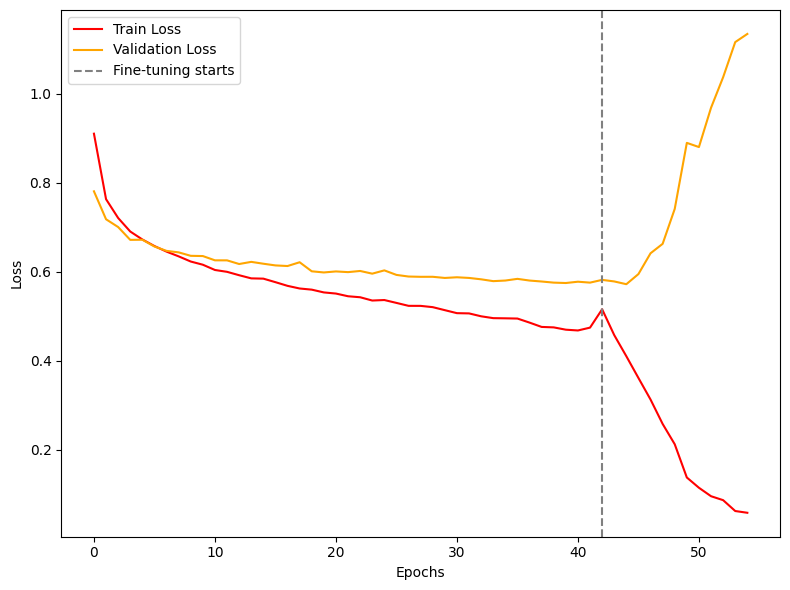

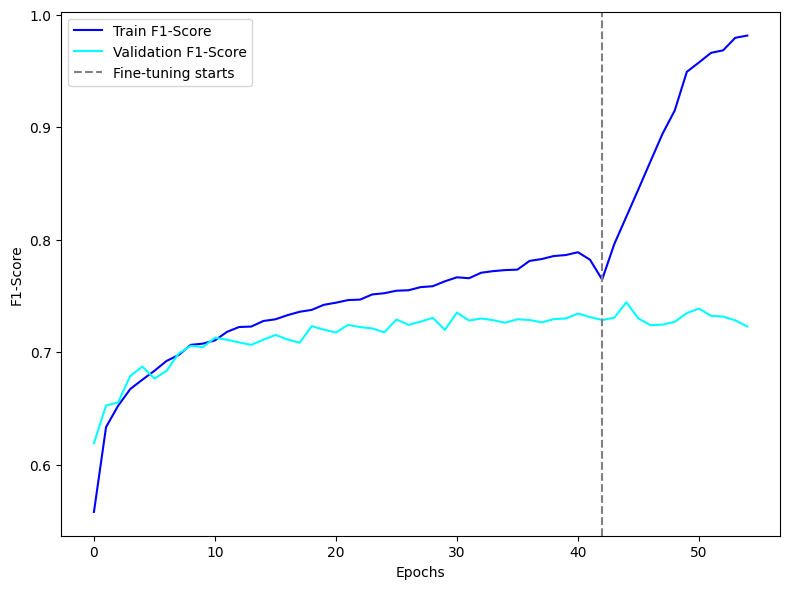

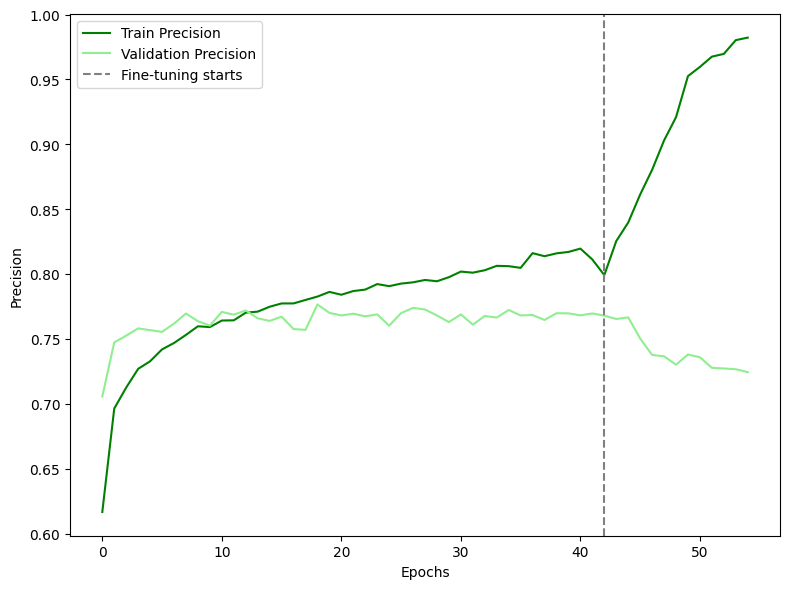

done1


In [15]:
# ==========================================================
# PLOT LEARNING CURVES (Loss, F1-Score, Precision)
# Phase 1 (frozen) and Phase 2 (fine-tuned) plotted as one continuous curve.
# ==========================================================
print("start")

def concat_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

phase1_end = len(history.history['loss'])

plt.figure(figsize=(8, 6))
plt.plot(concat_history(history, history_finetune, 'loss'), label='Train Loss', color='red')
plt.plot(concat_history(history, history_finetune, 'val_loss'), label='Validation Loss', color='orange')
plt.axvline(phase1_end, linestyle='--', color='gray', label='Fine-tuning starts')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.tight_layout()
plt.savefig("ResNet50_Wavelet_Balanced_Loss_Curve_v3.pdf", format='pdf', bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(concat_history(history, history_finetune, 'f1_score'), label='Train F1-Score', color='blue')
plt.plot(concat_history(history, history_finetune, 'val_f1_score'), label='Validation F1-Score', color='cyan')
plt.axvline(phase1_end, linestyle='--', color='gray', label='Fine-tuning starts')
plt.xlabel('Epochs'); plt.ylabel('F1-Score'); plt.legend(); plt.tight_layout()
plt.savefig("ResNet50_Wavelet_Balanced_F1_Curve_v3.pdf", format='pdf', bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(concat_history(history, history_finetune, 'precision'), label='Train Precision', color='green')
plt.plot(concat_history(history, history_finetune, 'val_precision'), label='Validation Precision', color='lightgreen')
plt.axvline(phase1_end, linestyle='--', color='gray', label='Fine-tuning starts')
plt.xlabel('Epochs'); plt.ylabel('Precision'); plt.legend(); plt.tight_layout()
plt.savefig("ResNet50_Wavelet_Balanced_Precision_Curve_v3.pdf", format='pdf', bbox_inches='tight')
plt.show()

print("done1")


In [16]:
# ==========================================================
# EVALUATION (Training, Validation & Testing)
# ==========================================================
print("Evaluating on Training Set...")
train_results = model.evaluate(train_generator)

print("\nEvaluating on Validation Set...")
val_results = model.evaluate(val_generator)

print("\nEvaluating on Testing Set (Truly Unseen)...")
test_results = model.evaluate(test_generator)

train_loss, train_acc, train_f1, train_precision, train_recall = train_results
val_loss, val_acc, val_f1, val_precision, val_recall = val_results
test_loss, test_acc, test_f1, test_precision, test_recall = test_results

for name, (loss, acc, f1, prec, rec) in [
    ("TRAINING", (train_loss, train_acc, train_f1, train_precision, train_recall)),
    ("VALIDATION", (val_loss, val_acc, val_f1, val_precision, val_recall)),
    ("TESTING (UNSEEN DATA)", (test_loss, test_acc, test_f1, test_precision, test_recall)),
]:
    print("\n" + "=" * 40)
    print(f"{name} METRICS")
    print("=" * 40)
    print(f"Loss      : {loss:.4f}")
    print(f"Accuracy  : {acc*100:.2f}%")
    print(f"F1-Score  : {f1*100:.2f}%")
    print(f"Precision : {prec*100:.2f}%")
    print(f"Recall    : {rec*100:.2f}%")


Evaluating on Training Set...
563/563 [==============================] - 246s 436ms/step - loss: 0.3059 - accuracy: 0.8858 - f1_score: 0.8633 - precision: 0.8776 - recall: 0.8416

Evaluating on Validation Set...
93/93 [==============================] - 42s 448ms/step - loss: 0.5725 - accuracy: 0.7393 - f1_score: 0.7445 - precision: 0.7666 - recall: 0.7113

Evaluating on Testing Set (Truly Unseen)...
92/92 [==============================] - 48s 520ms/step - loss: 0.5818 - accuracy: 0.7350 - f1_score: 0.7383 - precision: 0.7578 - recall: 0.7061

TRAINING METRICS
Loss      : 0.3059
Accuracy  : 88.58%
F1-Score  : 86.33%
Precision : 87.76%
Recall    : 84.16%

VALIDATION METRICS
Loss      : 0.5725
Accuracy  : 73.93%
F1-Score  : 74.45%
Precision : 76.66%
Recall    : 71.13%

TESTING (UNSEEN DATA) METRICS
Loss      : 0.5818
Accuracy  : 73.50%
F1-Score  : 73.83%
Precision : 75.78%
Recall    : 70.61%


In [17]:
# ==========================================================
# PRECISION, RECALL, F1-SCORE (Test Set - Unseen Data)
# ==========================================================
print("\nCalculating Precision, Recall, F1-score on Test Set...")

predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_names = test_generator.class_names

print("\nClassification Report (Test Set):\n")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

print("done1")



Calculating Precision, Recall, F1-score on Test Set...
92/92 [==============================] - 44s 467ms/step

Classification Report (Test Set):

              precision    recall  f1-score   support

      Benign       0.60      0.63      0.62       888
   Malignant       0.76      0.74      0.75      1266
      Normal       0.85      0.85      0.85       789

    accuracy                           0.73      2943
   macro avg       0.74      0.74      0.74      2943
weighted avg       0.74      0.73      0.74      2943

done1


Generating Confusion Matrix...


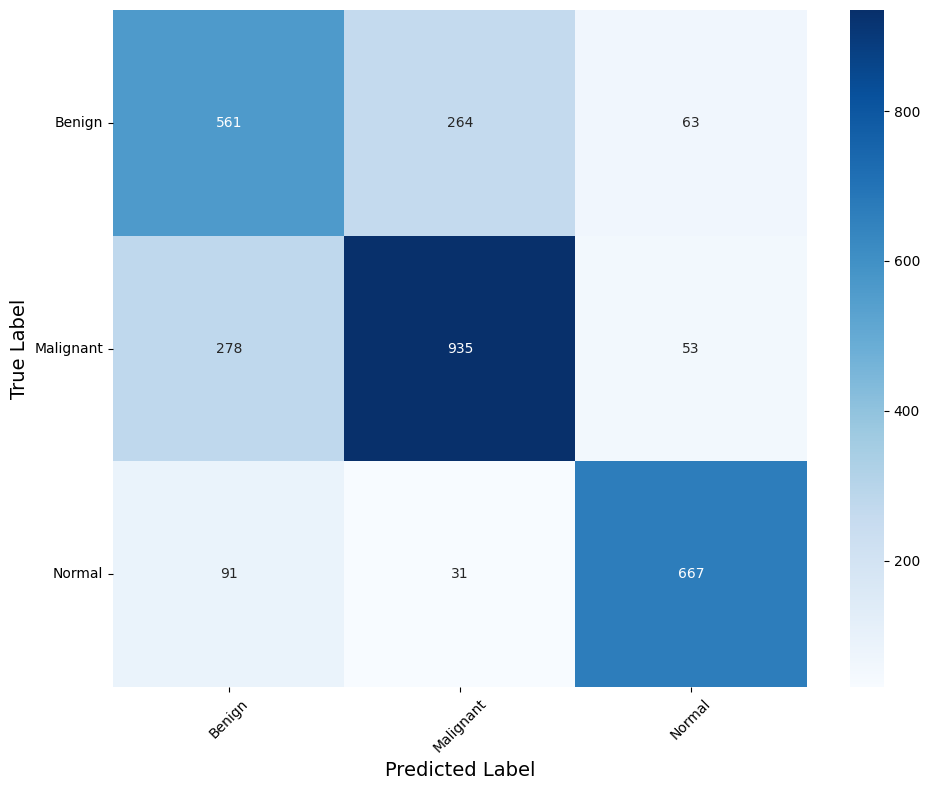


Raw confusion matrix (rows = true label, columns = predicted label):
Classes: ['Benign', 'Malignant', 'Normal']
[[561 264  63]
 [278 935  53]
 [ 91  31 667]]

Per-class error breakdown (where each class's mistakes actually go):

  True Benign (n=888): 561 correct (63.2%)
    -> misclassified as Malignant: 264 (29.7% of all Benign cases)
    -> misclassified as Normal: 63 (7.1% of all Benign cases)

  True Malignant (n=1266): 935 correct (73.9%)
    -> misclassified as Benign: 278 (22.0% of all Malignant cases)
    -> misclassified as Normal: 53 (4.2% of all Malignant cases)

  True Normal (n=789): 667 correct (84.5%)
    -> misclassified as Benign: 91 (11.5% of all Normal cases)
    -> misclassified as Malignant: 31 (3.9% of all Normal cases)

Benign-vs-Malignant target metric (n=2154, true label is Benign or Malignant; any other prediction -- including Normal -- counts as wrong):
  Accuracy: 69.45%
done1


In [18]:
# ==========================================================
# CONFUSION MATRIX -- PLOT, RAW NUMBERS, AND BENIGN-VS-MALIGNANT-ONLY ACCURACY  (v2: last two new)
# ==========================================================
print("Generating Confusion Matrix...")

import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("ResNet50_Wavelet_confusion_matrix_test_v3.pdf", format='pdf', bbox_inches='tight')
plt.show()

print("\nRaw confusion matrix (rows = true label, columns = predicted label):")
print("Classes:", class_names)
print(cm)

print("\nPer-class error breakdown (where each class's mistakes actually go):")
for i, true_cls in enumerate(class_names):
    total = cm[i].sum()
    if total == 0:
        continue
    correct = cm[i, i]
    print(f"\n  True {true_cls} (n={total}): {correct} correct ({100*correct/total:.1f}%)")
    for j, pred_cls in enumerate(class_names):
        if i == j:
            continue
        n_err = cm[i, j]
        if n_err > 0:
            print(f"    -> misclassified as {pred_cls}: {n_err} ({100*n_err/total:.1f}% of all {true_cls} cases)")

b_idx = class_names.index("Benign")
m_idx = class_names.index("Malignant")
pair_mask = np.isin(true_classes, [b_idx, m_idx])
if pair_mask.sum() > 0:
    pair_true = true_classes[pair_mask]
    pair_pred = predicted_classes[pair_mask]
    pair_acc = float(np.mean(pair_true == pair_pred))
    print(f"\nBenign-vs-Malignant target metric (n={int(pair_mask.sum())}, true label is Benign or "
          f"Malignant; any other prediction -- including Normal -- counts as wrong):")
    print(f"  Accuracy: {pair_acc*100:.2f}%")

print("done1")


## Notes & tunable hyperparameters (v3)

- **`CLASS_WEIGHT_MAX_MULTIPLIER` (3.0)** -- if the measured Benign/Malignant weights come out large
  (e.g. one class's recall is very low on val), this caps how far either can be pushed. Lower it if a
  large weight destabilizes Phase 2 training.
- **GLCM settings (`GLCM_LEVELS`, `GLCM_DISTANCES`, `GLCM_ANGLES`)** -- reduce these first if training
  speed drops noticeably, before dropping GLCM features altogether.
- **The Benign-vs-Malignant-only accuracy** printed at the end is the number to compare directly against
  this run's implicit baseline (recall 0.57 Benign / 0.82 Malignant, i.e. roughly consistent with a
  Benign-vs-Malignant accuracy 70.06% in v2, before the weight-floor fix) -- if it doesn't move up meaningfully from there
  meaningfully, the GLCM features and measured weighting aren't enough on their own, and the next
  candidate (not attempted here) would be the same dedicated two-stage cascade idea used in the
  semi-supervised line's v6: a separate Normal-vs-Abnormal stage feeding a dedicated Benign-vs-Malignant
  specialist, rather than one shared 3-class head.
- Two-phase structure, dropout (0.3), and `unfreeze last 30 layers` are unchanged -- they're already
  producing the best result across this whole project, so there's no evidence yet they need adjusting.
